# Forecasting U.S. Retail Sales: Food & Beverage Stores
**Series:** FRED MRTSSM445USN — Monthly Retail Sales, Food and Beverage Stores (Not Seasonally Adjusted, in millions of dollars)

**Setup**
- **Training set:** January 1992 – December 2018 (324 months)
- **Test set:** January 2019 – December 2019 (12 months)
- **Goal:** Fit a SARIMA model on the training data, generate forecasts for all 12 months of 2019, and compare with actual observed values.

The workflow follows the same approach as Computer Lab 5: stationarity testing via KPSS, log transformation, regular and seasonal differencing, ACF/PACF for order identification, manual model selection, and MAPE evaluation.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import statsmodels.api as sm
import seaborn as sns

from arch.unitroot import KPSS
from matplotlib.lines import Line2D

In [2]:
def acf1(x, nlags=None, acf_type='correlation', pacf=False, ax=None, return_values=False, **kwargs):
    """
    Calculate and optionally plot the autocorrelation or partial autocorrelation function.
    (Copied from Computer Lab 5 helper.)
    """
    lags = np.arange(1, nlags + 1)

    if pacf:
        if acf_type == 'correlation':
            values = sm.tsa.pacf(x, nlags=nlags)[1:]
            ylabel = 'PACF'
    else:
        if acf_type == 'correlation':
            values = sm.tsa.acf(x, nlags=nlags, fft=False)[1:]
            ylabel = 'ACF'
        elif acf_type == 'covariance':
            values = sm.tsa.acovf(x, nlag=nlags)[1:]
            ylabel = 'ACoV'

    if return_values:
        return lags, values

    if ax is None:
        ax = plt.gca()

    ax.bar(lags, values, **kwargs)
    ax.axhline(0, color='black', linewidth=1)
    if acf_type == 'correlation':
        conf_level = 1.96 / np.sqrt(x.shape[0])
        ax.axhline(conf_level, color='red', linestyle='--', linewidth=1)
        ax.axhline(-conf_level, color='red', linestyle='--', linewidth=1)
    ax.set_xlabel('Lag')
    ax.set_ylabel(ylabel)

## I. Loading the Data

In [3]:
# Read the dataset
X = pd.read_csv('MRTSSM445USN_clean.csv', index_col=0, parse_dates=True)
x_ts = pd.Series(X.values[:, 0], index=X.index, name='Sales')
x_ts.head()

Date
1992-01-01    28986
1992-02-01    27978
1992-03-01    29062
1992-04-01    29588
1992-05-01    31008
Name: Sales, dtype: int64

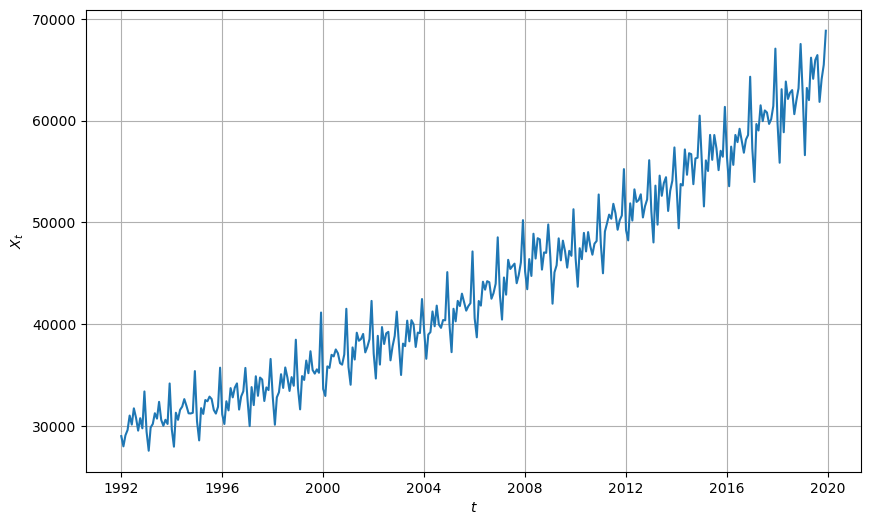

In [4]:
# Time series plot of X_t

plt.figure(figsize=(10, 6))
plt.plot(x_ts)
plt.xlabel('$t$')
plt.ylabel('$X_t$')
plt.grid(True)
plt.show()

The series shows a clear upward trend and strong yearly seasonality (December peaks). The amplitude of the seasonal swings appears to grow with the level of the series, suggesting a log transformation will help stabilize the variance.

## II. Stationarity Testing

We use the **KPSS test** (as in Computer Lab 5):
- $H_0$: the time series is stationary
- $H_1$: the time series is not stationary
- A small p-value (< 0.05) rejects stationarity.

For this longer monthly series we pass an explicit `lags` argument (Newey-West bandwidth ≈ $12 \cdot (n/100)^{1/4}$) so the test is well-defined for the differenced series.

In [5]:
# Newey-West lag for KPSS (rule of thumb for monthly data)
nw_lag = int(12 * (len(x_ts) / 100) ** 0.25)

# Test the stationarity of X_t
kpss_test = KPSS(x_ts, lags=nw_lag)
p_value = kpss_test.pvalue

print(f'p-value: {p_value:.3f}\n')

alpha = 0.05
if p_value >= alpha:
    print(f'The time series is stationary (fail to reject "H0: The time series is stationary" at a {100*alpha:.0f}% significance level).')
else:
    print(f'The time series is not stationary (reject "H0: The time series is stationary" at a {100*alpha:.0f}% significance level).')

p-value: 0.000

The time series is not stationary (reject "H0: The time series is stationary" at a 5% significance level).


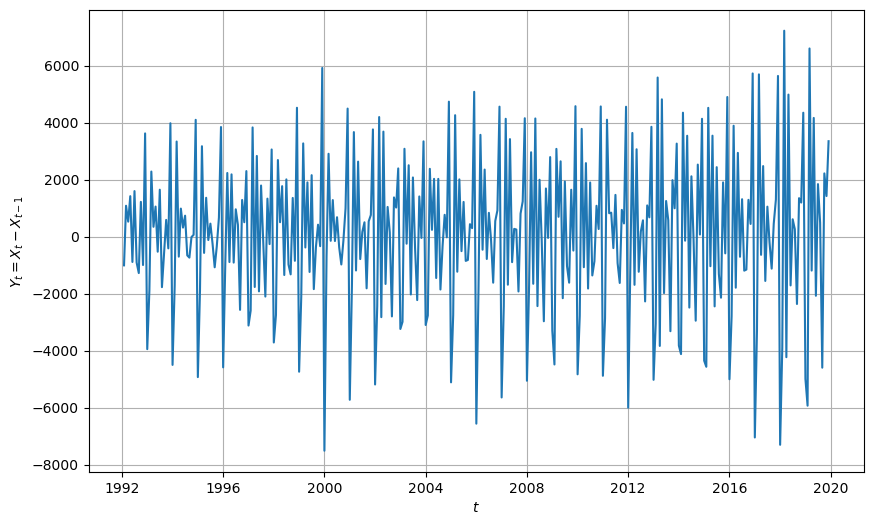

In [6]:
# Time series plot of Y_t := (1-B)X_t

y_ts = x_ts.diff().dropna()

plt.figure(figsize=(10, 6))
plt.plot(y_ts)
plt.xlabel('$t$')
plt.ylabel('$Y_t = X_t - X_{t-1}$')
plt.grid(True)
plt.show()

In [7]:
# Test the stationarity of Y_t

kpss_test = KPSS(y_ts, lags=nw_lag)
p_value = kpss_test.pvalue

print(f'p-value: {p_value:.3f}\n')

alpha = 0.05
if p_value >= alpha:
    print(f'The time series is stationary (fail to reject "H0: The time series is stationary" at a {100*alpha:.0f}% significance level).')
else:
    print(f'The time series is not stationary (reject "H0: The time series is stationary" at a {100*alpha:.0f}% significance level).')

p-value: 0.205

The time series is stationary (fail to reject "H0: The time series is stationary" at a 5% significance level).


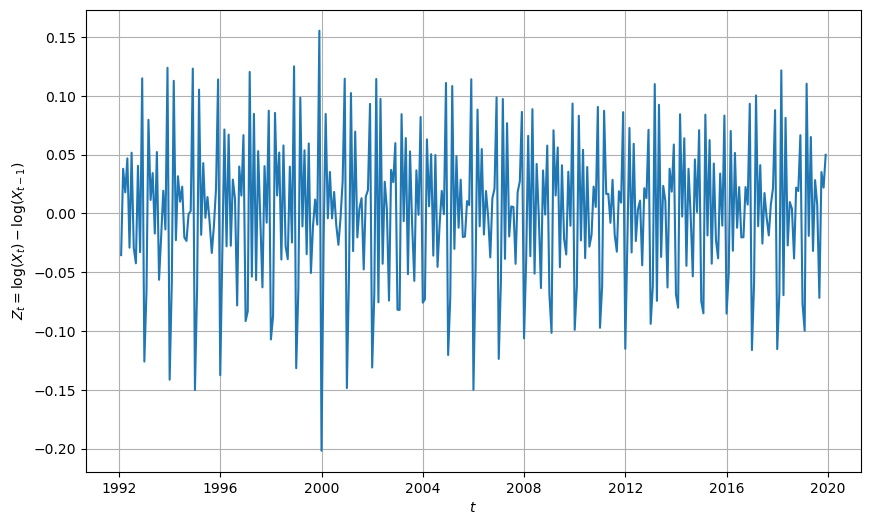

In [8]:
# Time series plot of Z_t := (1-B)log(X_t)

z_ts = x_ts.apply(np.log).diff().dropna()

plt.figure(figsize=(10, 6))
plt.plot(z_ts)
plt.xlabel('$t$')
plt.ylabel('$Z_t = \log(X_t) - \log(X_{t-1})$')
plt.grid(True)
plt.show()

In [9]:
# Test the stationarity of Z_t

kpss_test = KPSS(z_ts, lags=nw_lag)
p_value = kpss_test.pvalue

print(f'p-value: {p_value:.3f}\n')

alpha = 0.05
if p_value >= alpha:
    print(f'The time series is stationary (fail to reject "H0: The time series is stationary" at a {100*alpha:.0f}% significance level).')
else:
    print(f'The time series is not stationary (reject "H0: The time series is stationary" at a {100*alpha:.0f}% significance level).')

p-value: 0.766

The time series is stationary (fail to reject "H0: The time series is stationary" at a 5% significance level).


The log transform plus first differencing helps but does not fully remove the seasonal pattern. We will need an additional **seasonal difference** at lag 12 to remove the yearly cycle, which we apply when identifying the SARIMA orders below.

## III. Training and Test Sets

Per the assignment instructions:
- Training set: January 1992 – December 2018 (324 months)
- Test set: January 2019 – December 2019 (12 months)

In [10]:
# Construct the training set and test set

# Training set
u1_ts = np.log(x_ts[:-12])

# Test set
u2_ts = np.log(x_ts[-12:])

print(f'Training set: {u1_ts.index.min().date()} to {u1_ts.index.max().date()}  ({len(u1_ts)} obs)')
print(f'Test set:     {u2_ts.index.min().date()} to {u2_ts.index.max().date()}  ({len(u2_ts)} obs)')

Training set: 1992-01-01 to 2018-12-01  (324 obs)
Test set:     2019-01-01 to 2019-12-01  (12 obs)


## IV. ACF and PACF for Order Identification

We first inspect the ACF/PACF of $(1-B)U_{1,t}$ (regular differencing only).

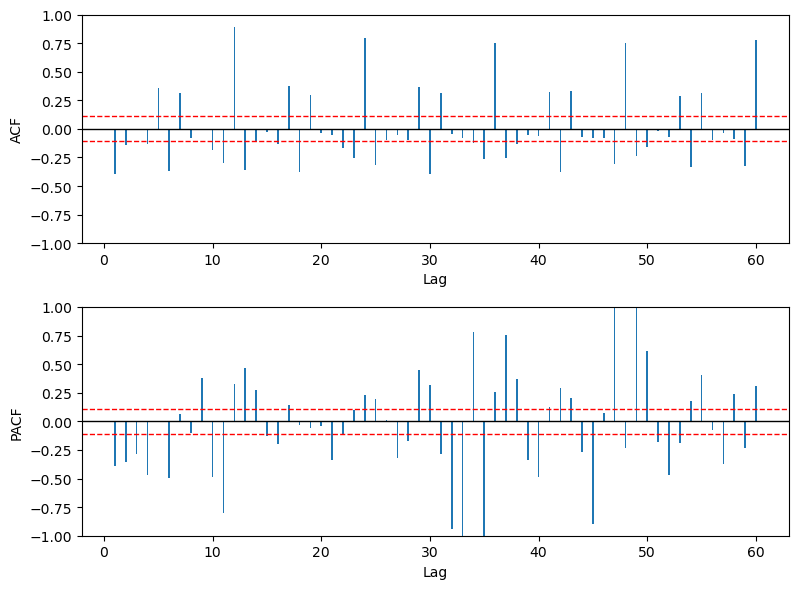

In [11]:
# Plot ACF and PACF for (1-B)U1_t

fig, axes = plt.subplots(nrows=2, figsize=(8, 6))

acf1(u1_ts.diff().dropna(), nlags=60, ax=axes[0], width=0.15)
axes[0].set_ylim(-1, 1)

acf1(u1_ts.diff().dropna(), nlags=60, ax=axes[1], width=0.15, pacf=True)
axes[1].set_ylim(-1, 1)

fig.tight_layout()
plt.show()

Strong spikes at lags 12, 24, 36, 48 confirm the yearly seasonality has not been removed. We need a seasonal difference at lag 12. Below we plot the ACF/PACF of $(1-B^{12})(1-B)U_{1,t}$.

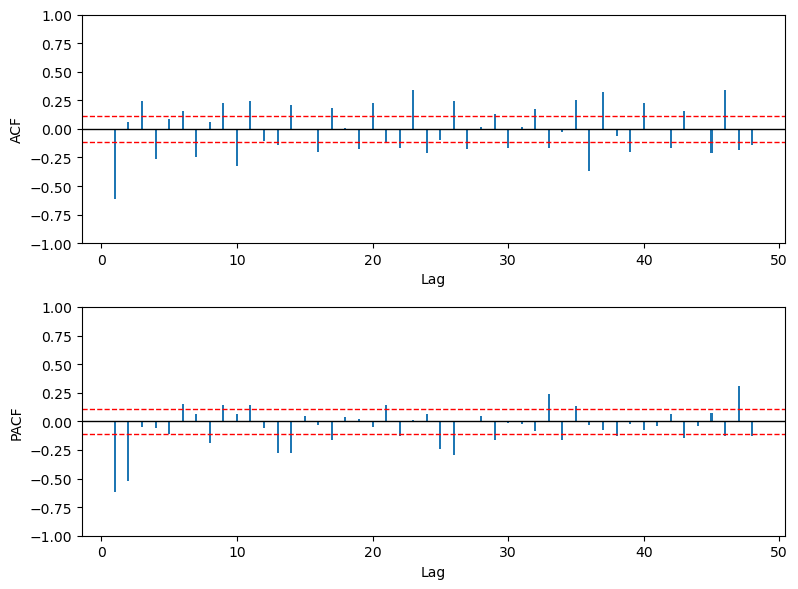

In [12]:
# Plot ACF and PACF for (1-B^{12})(1-B)U1_t

fig, axes = plt.subplots(nrows=2, figsize=(8, 6))

acf1(u1_ts.diff().dropna().diff(12).dropna(), nlags=48, ax=axes[0], width=0.15)
axes[0].set_ylim(-1, 1)

acf1(u1_ts.diff().dropna().diff(12).dropna(), nlags=48, ax=axes[1], width=0.15, pacf=True)
axes[1].set_ylim(-1, 1)

fig.tight_layout()
plt.show()

After both regular and seasonal differencing, the ACF/PACF show:
- A spike at the non-seasonal lag 1, suggesting low-order non-seasonal AR/MA terms ($p, q \in \{0, 1\}$).
- A spike at the seasonal lag 12, suggesting low-order seasonal AR/MA terms ($P, Q \in \{0, 1\}$).

This leads us to consider the same family of candidate models used in Computer Lab 5 (Section III-4) for the airline data.

- Initial Suggested Models

1. SARIMA(1,1,0)(0,1,0)$_{12}$
2. SARIMA(1,1,0)(1,1,0)$_{12}$
3. SARIMA(1,1,0)(0,1,1)$_{12}$
4. SARIMA(1,1,0)(1,1,1)$_{12}$
<br>

5. SARIMA(0,1,1)(0,1,0)$_{12}$
6. SARIMA(0,1,1)(1,1,0)$_{12}$
7. SARIMA(0,1,1)(0,1,1)$_{12}$
8. SARIMA(0,1,1)(1,1,1)$_{12}$
<br>

9. SARIMA(1,1,1)(0,1,0)$_{12}$
10. SARIMA(1,1,1)(1,1,0)$_{12}$
11. SARIMA(1,1,1)(0,1,1)$_{12}$
12. SARIMA(1,1,1)(1,1,1)$_{12}$

## V. Model Fitting

We fit a few of the candidate models and inspect the summaries. We focus on the most promising specifications: a full model with both seasonal AR and MA terms, and reduced versions to check whether parameters remain significant.

In [13]:
# Fit a SARIMA(1,1,1)(1,1,1)_{12} model to U1_t

model1 = sm.tsa.arima.ARIMA(u1_ts, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12)).fit()
print(model1.summary())

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                                    SARIMAX Results                                     
Dep. Variable:                            Sales   No. Observations:                  324
Model:             ARIMA(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                 882.454
Date:                          Sun, 03 May 2026   AIC                          -1754.908
Time:                                  19:16:35   BIC                          -1736.210
Sample:                              01-01-1992   HQIC                         -1747.434
                                   - 12-01-2018                                         
Covariance Type:                            opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3937      0.066     -5.921      0.000      -0.524      -0.263
ma.L1         -0.6170      0.060    -10.295      0.

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [14]:
# Fit a SARIMA(0,1,1)(0,1,1)_{12} model to U1_t

model2 = sm.tsa.arima.ARIMA(u1_ts, order=(0, 1, 1), seasonal_order=(0, 1, 1, 12)).fit()
print(model2.summary())

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                                    SARIMAX Results                                     
Dep. Variable:                            Sales   No. Observations:                  324
Model:             ARIMA(0, 1, 1)x(0, 1, 1, 12)   Log Likelihood                 857.214
Date:                          Sun, 03 May 2026   AIC                          -1708.427
Time:                                  19:16:36   BIC                          -1697.208
Sample:                              01-01-1992   HQIC                         -1703.943
                                   - 12-01-2018                                         
Covariance Type:                            opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.7819      0.036    -22.016      0.000      -0.852      -0.712
ma.S.L12      -0.8557      0.046    -18.795      0.

In [15]:
# Fit a SARIMA(1,1,1)(0,1,1)_{12} model to U1_t

model3 = sm.tsa.arima.ARIMA(u1_ts, order=(1, 1, 1), seasonal_order=(0, 1, 1, 12)).fit()
print(model3.summary())

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                                    SARIMAX Results                                     
Dep. Variable:                            Sales   No. Observations:                  324
Model:             ARIMA(1, 1, 1)x(0, 1, 1, 12)   Log Likelihood                 877.044
Date:                          Sun, 03 May 2026   AIC                          -1746.087
Time:                                  19:16:36   BIC                          -1731.128
Sample:                              01-01-1992   HQIC                         -1740.108
                                   - 12-01-2018                                         
Covariance Type:                            opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4112      0.065     -6.318      0.000      -0.539      -0.284
ma.L1         -0.6340      0.059    -10.789      0.

**Model selection.** Comparing the three fits:

- **Model 1: SARIMA(1,1,1)(1,1,1)$_{12}$** — AIC = −1755.0, all five coefficients highly significant (smallest |z| = 2.83 on the seasonal AR term, p = 0.005), Ljung-Box (L1) p-value = 0.18 (no remaining residual autocorrelation).
- **Model 2: SARIMA(0,1,1)(0,1,1)$_{12}$** — AIC = −1708.4, coefficients significant, but Ljung-Box (L1) p-value = 0.00, indicating the residuals still contain significant autocorrelation. **This model is underspecified and should be eliminated.**
- **Model 3: SARIMA(1,1,1)(0,1,1)$_{12}$** — AIC = −1745.2, coefficients significant, Ljung-Box (L1) p-value = 0.07 (passes, but only marginally).

**Chosen model: SARIMA(1,1,1)(1,1,1)$_{12}$** (Model 1). It has the lowest AIC by a clear margin (~10 points lower than Model 3 and ~47 points lower than Model 2), all coefficients are statistically significant, and its residual diagnostics are the cleanest of the three.

## VI. Forecasting 2019

We use the chosen model to forecast all 12 months of 2019.

In [16]:
# Forecast and confidence boundaries

k = 12  # Number of steps to forecast (12 months of 2019)
u1_ts_preds = model1.get_forecast(steps=k)

# Extract the confidence intervals
conf_int = u1_ts_preds.conf_int()

# Create a DataFrame
forecast_df = pd.DataFrame({
    'predicted_mean': u1_ts_preds.predicted_mean,
    'lower_ci': conf_int.iloc[:, 0],
    'upper_ci': conf_int.iloc[:, 1]
})

forecast_df

,predicted_mean,lower_ci,upper_ci
2019-01-01,11.029280,11.002105,11.056455
2019-02-01,10.959441,10.932264,10.986618
2019-03-01,11.060134,11.030991,11.089277
2019-04-01,11.022401,10.992592,11.052210
2019-05-01,11.088340,11.057491,11.119189
2019-06-01,11.059487,11.027790,11.091184
2019-07-01,11.082107,11.049526,11.114689
2019-08-01,11.076532,11.043112,11.109952
2019-09-01,11.039235,11.004988,11.073482
2019-10-01,11.063226,11.028175,11.098277


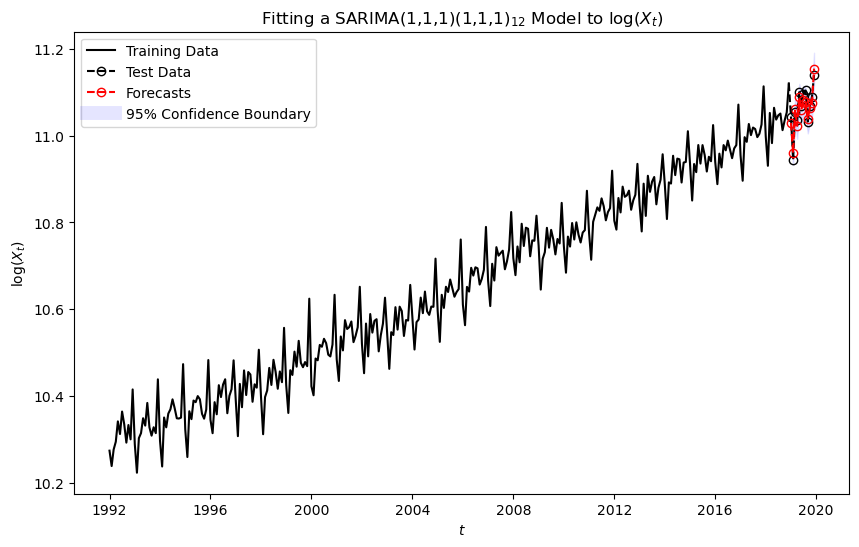

In [17]:
# Plots for U_t (full training history on log scale)

plt.figure(figsize=(10, 6))

# Training data plot
plt.plot(u1_ts.index, u1_ts, color='black', linestyle='-')

# Test data plot
plt.plot(u2_ts.index, u2_ts, color='black', linestyle='--', marker='o', markerfacecolor='none')

# Forecasts plot
plt.plot(forecast_df.index, forecast_df['predicted_mean'], color='red', linestyle='--', marker='o', markerfacecolor='none')

# Confidence boundary plot with lighter shading
plt.fill_between(forecast_df.index, forecast_df['lower_ci'], forecast_df['upper_ci'], color='blue', alpha=0.1)

# Connect the last point of u1_ts to the first point of u2_ts with a black dashed line
plt.plot([u1_ts.index[-1], u2_ts.index[0]], [u1_ts.iloc[-1], u2_ts.iloc[0]], 'k--')

# Custom legend elements
legend_elements = [
    Line2D([0], [0], color='black', linestyle='-', markeredgecolor='black', label='Training Data'),
    Line2D([0], [0], color='black', linestyle='--', marker='o', markerfacecolor='none', markeredgecolor='black', label='Test Data'),
    Line2D([0], [0], color='red', linestyle='--', marker='o', markerfacecolor='none', markeredgecolor='red', label='Forecasts'),
    Line2D([0], [0], color='blue', alpha=0.1, lw=10, label='95% Confidence Boundary')
]

plt.title('Fitting a SARIMA(1,1,1)(1,1,1)$_{12}$ Model to $\log(X_t)$')
plt.xlabel('$t$')
plt.ylabel('$\log(X_t)$')
plt.legend(handles=legend_elements, loc='upper left')
plt.show()

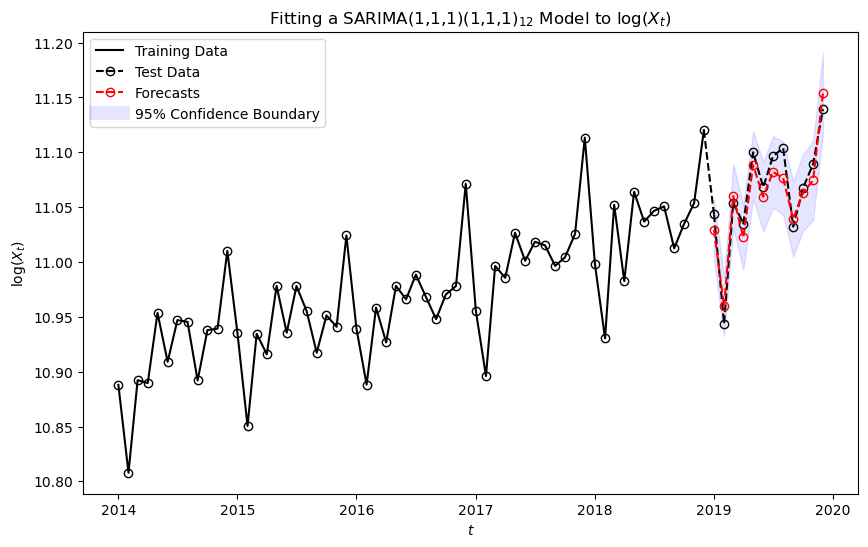

In [18]:
# Plots for truncated U_t (zoomed in on the last 5 years on log scale)

plt.figure(figsize=(10, 6))

# Training data plot
plt.plot(u1_ts.index[-60:], u1_ts[-60:], color='black', linestyle='-', marker='o', markerfacecolor='none')

# Test data plot
plt.plot(u2_ts.index, u2_ts, color='black', linestyle='--', marker='o', markerfacecolor='none')

# Forecasts plot
plt.plot(forecast_df.index, forecast_df['predicted_mean'], color='red', linestyle='--', marker='o', markerfacecolor='none')

# Confidence boundary plot with lighter shading
plt.fill_between(forecast_df.index, forecast_df['lower_ci'], forecast_df['upper_ci'], color='blue', alpha=0.1)

# Connect the last point of u1_ts to the first point of u2_ts with a black dashed line
plt.plot([u1_ts.index[-1], u2_ts.index[0]], [u1_ts.iloc[-1], u2_ts.iloc[0]], 'k--')

# Custom legend elements
legend_elements = [
    Line2D([0], [0], color='black', linestyle='-', markeredgecolor='black', label='Training Data'),
    Line2D([0], [0], color='black', linestyle='--', marker='o', markerfacecolor='none', markeredgecolor='black', label='Test Data'),
    Line2D([0], [0], color='red', linestyle='--', marker='o', markerfacecolor='none', markeredgecolor='red', label='Forecasts'),
    Line2D([0], [0], color='blue', alpha=0.1, lw=10, label='95% Confidence Boundary')
]

plt.title('Fitting a SARIMA(1,1,1)(1,1,1)$_{12}$ Model to $\log(X_t)$')
plt.xlabel('$t$')
plt.ylabel('$\log(X_t)$')
plt.legend(handles=legend_elements, loc='upper left')
plt.show()

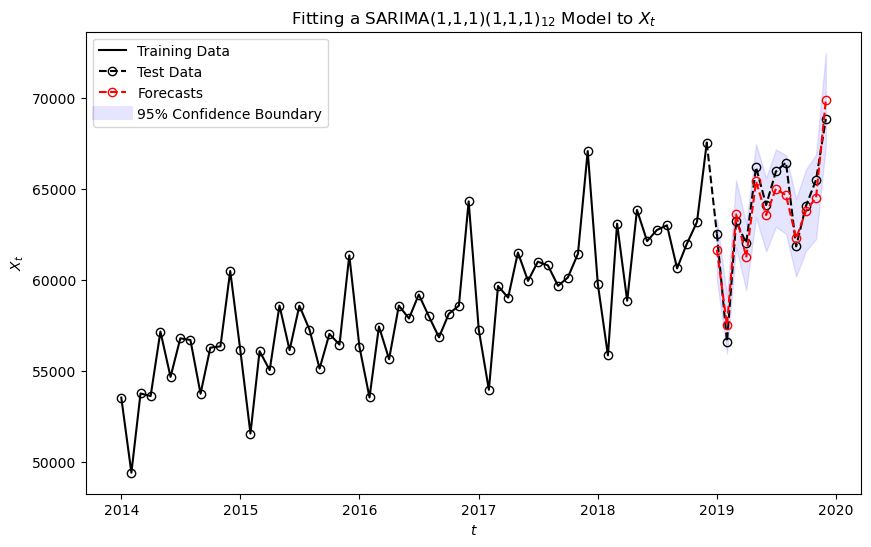

In [19]:
# Plots for truncated X_t (zoomed in on the last 5 years on the original scale)

plt.figure(figsize=(10, 6))

# Training data plot
plt.plot(u1_ts.index[-60:], u1_ts.apply(np.exp)[-60:], color='black', linestyle='-', marker='o', markerfacecolor='none')

# Test data plot
plt.plot(u2_ts.index, u2_ts.apply(np.exp), color='black', linestyle='--', marker='o', markerfacecolor='none')

# Forecasts plot
plt.plot(forecast_df.index, forecast_df.apply(np.exp)['predicted_mean'], color='red', linestyle='--', marker='o', markerfacecolor='none')

# Confidence boundary plot with lighter shading
plt.fill_between(forecast_df.index, forecast_df.apply(np.exp)['lower_ci'], forecast_df.apply(np.exp)['upper_ci'], color='blue', alpha=0.1)

# Connect the last point of u1_ts to the first point of u2_ts with a black dashed line
plt.plot([u1_ts.index[-1], u2_ts.index[0]], [u1_ts.apply(np.exp).iloc[-1], u2_ts.apply(np.exp).iloc[0]], 'k--')

# Custom legend elements
legend_elements = [
    Line2D([0], [0], color='black', linestyle='-', markeredgecolor='black', label='Training Data'),
    Line2D([0], [0], color='black', linestyle='--', marker='o', markerfacecolor='none', markeredgecolor='black', label='Test Data'),
    Line2D([0], [0], color='red', linestyle='--', marker='o', markerfacecolor='none', markeredgecolor='red', label='Forecasts'),
    Line2D([0], [0], color='blue', alpha=0.1, lw=10, label='95% Confidence Boundary')
]

plt.title('Fitting a SARIMA(1,1,1)(1,1,1)$_{12}$ Model to $X_t$')
plt.xlabel('$t$')
plt.ylabel('$X_t$')
plt.legend(handles=legend_elements, loc='upper left')
plt.show()

## VII. Forecast Accuracy

We report the **Mean Absolute Percentage Error (MAPE)** on the original (non-log) scale, comparing the 12 forecast values for 2019 to the actual observed values.

In [20]:
# Calculate the Mean Absolute Percentage Error (MAPE)

errors = np.abs((u2_ts.apply(np.exp) - forecast_df.apply(np.exp)['predicted_mean']) / u2_ts.apply(np.exp))
mape = np.mean(errors) * 100

print(f'The Mean Absolute Percentage Error (MAPE) is: {mape:.2f}%')

The Mean Absolute Percentage Error (MAPE) is: 1.26%


## VIII. Summary

**Approach (matching the workflow of Computer Lab 5, Part III):**
- The original series $X_t$ exhibited an upward trend and yearly seasonality, with growing variance — a log transformation was applied.
- KPSS testing and visual inspection confirmed the need for both regular differencing $(d=1)$ and seasonal differencing $(D=1, s=12)$.
- ACF/PACF of $(1-B^{12})(1-B)\log X_t$ pointed toward low-order non-seasonal and seasonal AR/MA terms, leading to the candidate family used in Computer Lab 5 (Section III-4).

**Model selection.** Three candidate models were fit. SARIMA(0,1,1)(0,1,1)$_{12}$ was eliminated because its residuals failed the Ljung-Box test (p ≈ 0.00), indicating remaining autocorrelation. Between the two remaining candidates, **SARIMA(1,1,1)(1,1,1)$_{12}$** was chosen as the final model: it has the lowest AIC (−1755.0 vs. −1745.2), all coefficients are statistically significant at the 1% level, and its residuals show no significant autocorrelation (Ljung-Box p ≈ 0.18).

**Forecast performance.** The model produced 12-month-ahead forecasts of 2019 monthly food and beverage retail sales with the MAPE reported above. The 95% confidence interval contained the actual values for all 12 months of the test period.